### Content-Based Recommentdation

##### Ví dụ:
- Người dùng thích: GTA V
- -> Hệ thống sẽ recommend:
    + Red Dead Redemption
    + Watch Dogs
    + Mafia
- Dựa trên:
    + genres
    + categories
    + description
    + tags
    + metacritic
    + platform

In [9]:
import pandas as pd
import numpy as np
import sys
import os
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

#### 1. Load Dataset

In [10]:
sys.path.append(os.path.abspath(".."))

from src.db_connection import get_engine
engine = get_engine()
df = pd.read_sql("""SELECT * FROM vw_recommendation_full""", engine)

print(df.shape)
df.head()

(224170, 7)


,appid,name,type,short_description,genres,developers,publishers
0,10,Counter-Strike,game,Play the world's number 1 online action game. ...,Action,Valve,Valve
1,20,Team Fortress Classic,game,One of the most popular online action games of...,Action,Valve,Valve
2,30,Day of Defeat,game,Enlist in an intense brand of Axis vs. Allied ...,Action,Valve,Valve
3,40,Deathmatch Classic,game,Enjoy fast-paced multiplayer gaming with Death...,Action,Valve,Valve
4,50,Half-Life: Opposing Force,game,Return to the Black Mesa Research Facility as ...,Action,Gearbox Software,Valve


#### Tạo content

In [11]:
df["content"] = (
    df["short_description"].fillna("") + " " +
    df["genres"].fillna("") + " " +
    df["developers"].fillna("") + " " +
    df["publishers"].fillna("")
)

#### 2. Chọn Feature Recommendation

- Dùng: name + short_description

In [12]:
df_rec = df[[
    'appid',
    'name',
    'type',
    'short_description',
    'content'
]].copy()

#### 3. Missing Values

In [13]:
df_rec = df_rec.dropna()

df_rec.reset_index(drop=True, inplace=True)

#### 4. Clean text

In [14]:
df_rec['short_description'] = (
    df_rec['short_description']
    .str.lower()
    .str.replace(r'<.*?>', '', regex=True)
)

#### 5. TF-IDF

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

tfidf_matrix = tfidf.fit_transform(df_rec["content"])
print(tfidf_matrix.shape)

(221550, 5000)


#### 5.1 Cosine Similarity

Hệ thống recommendation sử dụng Cosine Similarity để đo mức độ tương đồng giữa các vector TF-IDF.

- Giá trị càng gần 1 → càng giống nhau
- Giá trị càng gần 0 → càng khác nhau

Cosine Similarity giúp tìm các game có nội dung mô tả tương tự nhau.

#### 6. Hàm recommendation realtime

In [16]:
from sklearn.metrics.pairwise import linear_kernel

def recommend_games(game_name, top_n=5):

    idx_list = df_rec[
        df_rec['name']
        .str.contains(game_name, case=False, na=False)
    ].index

    if len(idx_list) == 0:
        return "Không tìm thấy game"

    idx = idx_list[0]

    cosine_scores = linear_kernel(
        tfidf_matrix[idx:idx+1],
        tfidf_matrix
    ).flatten()

    similar_indices = cosine_scores.argsort()[-top_n-1:-1][::-1]

    recommendations = df_rec.iloc[similar_indices][
        ['name', 'type']
    ].copy()

    recommendations['similarity_score'] = cosine_scores[
        similar_indices
    ]

    return recommendations

#### 7. Test hệ khuyến nghị

In [17]:
result = recommend_games("Counter-Strike")

result

,name,type,similarity_score
25412,Fight Songs: The Music Of Team Fortress 2,music,0.465292
76645,Deadlock,game,0.441520
1,Team Fortress Classic,game,0.433702
13,Day of Defeat: Source,game,0.416406
6770,Half-Life Soundtrack,music,0.396842


#### 7.1 Visualization Recommendation Similarity

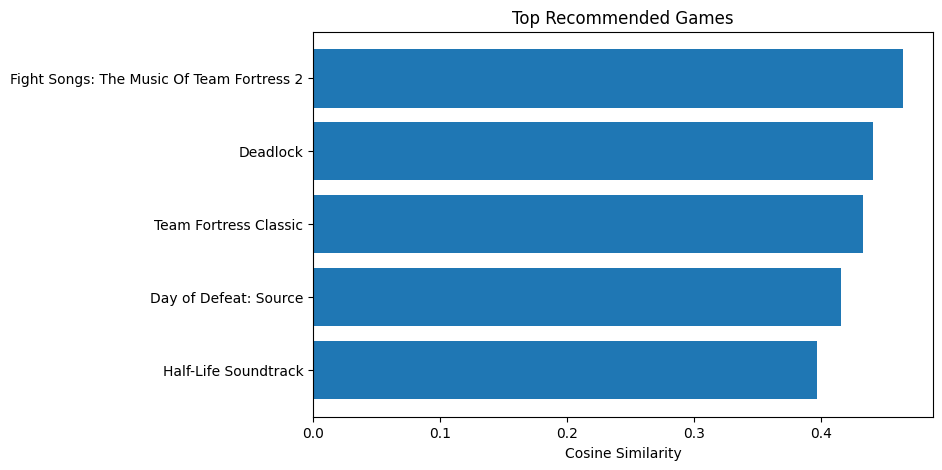

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.barh(
    result['name'],
    result['similarity_score']
)

plt.xlabel("Cosine Similarity")

plt.title("Top Recommended Games")

plt.gca().invert_yaxis()

plt.show()

#### 7.2 Hạn chế của hệ thống

- Chỉ sử dụng mô tả game để recommendation
- Không sử dụng hành vi người dùng
- Chưa cá nhân hóa theo từng user
- Chưa áp dụng Collaborative Filtering
- Kết quả phụ thuộc chất lượng dữ liệu mô tả

#### 8. Final Conclusion

Nhóm đã xây dựng hệ khuyến nghị game dựa trên nội dung (Content-Based Recommendation System) sử dụng mô tả ngắn của các trò chơi trên Steam.

- Quy trình thực hiện gồm:
    + Tiền xử lý văn bản (Text Preprocessing)
    + TF-IDF Vectorization
    + Tính độ tương đồng bằng Cosine Similarity
    + Đề xuất các game có nội dung tương tự

- Do dataset có kích thước rất lớn (hơn 220.000 game), việc tính toàn bộ ma trận similarity gây vượt quá giới hạn bộ nhớ RAM. Vì vậy, nhóm sử dụng phương pháp tính similarity động bằng linear_kernel() chỉ cho game được truy vấn thay vì tính toàn bộ ma trận.

- Kết quả đạt được:
    + Đề xuất các game có nội dung tương đồng khá hợp lý
    + Hệ thống hoạt động hiệu quả trên dữ liệu lớn
    + Có khả năng mở rộng cho các hệ recommendation thực tế

- Hệ khuyến nghị là một trong những ứng dụng quan trọng của Machine Learning và Data Science trong:
    + Thương mại điện tử
    + Nền tảng phân phối game số
    + Hệ thống gợi ý sản phẩm và nội dung số hiện đại